In [1]:
from pytoda.smiles.smiles_language import SMILESLanguage, SMILESTokenizer
from pytoda.smiles.processing import tokenize_smiles
from importlib import resources
from pytoda.smiles.smiles_language import SMILESTokenizer
import os
import re
from rdkit import Chem
import sys
from rdkit import RDConfig

efg_dir = os.path.join(RDConfig.RDContribDir, "efgs")
sys.path.insert(0, efg_dir)
import efgs

import pandas as pd
import json

In [ ]:

tokenizer = SMILESTokenizer(vocab_file=str(vocab_path),
                            canonical= True,
                            sanitize= True)


NameError: name 'vocab_path' is not defined

In [13]:
canonical_smiles.to_csv('Data/pt_canon_smiles.csv')

KeyboardInterrupt: 

In [ ]:
tokenizer.add_token('<MASK>')

In [ ]:


save_dir = "./smiles_tokenizer_pytoda"
os.makedirs(save_dir, exist_ok=True)

tokenizer.save_pretrained(save_dir)

tokenizer.save_pretrained('./smiles_tokenizer_pytoda')

('./smiles_tokenizer_pytoda/vocab.json',
 './smiles_tokenizer_pytoda/token_count.json')

In [2]:
tokenizer=SMILESTokenizer(vocab_file='smiles_tokenizer_pytoda/vocab.json',
                          canonical=True,
                          sanitize=True)

In [6]:
tokenizer.padding_index

0

In [ ]:


def mask_fg_full_span(smiles, tokenizer):
    # -------------------------------------------------
    # 1️⃣ Canonicalize
    # -------------------------------------------------
    # canonical = tokenizer.transform_smiles(smiles)

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # -------------------------------------------------
    # 2️⃣ Atom map 번호 부여
    # -------------------------------------------------
    for atom in mol.GetAtoms():
        atom.SetAtomMapNum(atom.GetIdx()+1)

    mapped = Chem.MolToSmiles(mol, canonical=True)

    # -------------------------------------------------
    # 3️⃣ Tokenize
    # -------------------------------------------------
    mapped_tokens = tokenizer.smiles_tokenizer(mapped)
    smi_tokens = tokenizer.smiles_tokenizer(smiles)
    print(smi)
    # -------------------------------------------------
    # 4️⃣ FG atom ids 추출
    # -------------------------------------------------
    _, fg_atom_sets, a, _ = efgs.get_dec_fgs(mol)
    fg_atoms = set().union(*fg_atom_sets)
    print(fg_atom_sets)
    print(len(fg_atoms))
    print(a)
    # -------------------------------------------------
    # 5️⃣ 각 토큰의 atom id 추출
    # -------------------------------------------------
    token_atom = []
    for tok in mapped_tokens:
        m = re.search(r":(\d+)\]", tok)
        if m:
            token_atom.append(int(m.group(1))-1)
        else:
            token_atom.append(None)
    print(token_atom)
    # -------------------------------------------------
    # 6️⃣ FG seed token 찾기 (원자 토큰)
    # -------------------------------------------------
    seed_positions = {
        i for i, atom_id in enumerate(token_atom)
        if atom_id is not None and atom_id in fg_atom_sets[1]
    }
    print(seed_positions)
    # -------------------------------------------------
    # 7️⃣ span 확장 (결합/괄호/고리숫자까지)
    # -------------------------------------------------
    mask_positions = set(seed_positions)

    structural_tokens = set([
        "=", "#", "-", "/", "\\",
        "(", ")",
    ])

    ring_pattern = re.compile(r"%\d\d|\d")

    changed = True
    while changed:
        changed = False
        for i, tok in enumerate(smi_tokens):
            if i in mask_positions:
                continue

            # 양옆에 마스크 토큰이 있으면 구조 토큰도 포함
            if (
                (i - 1 in mask_positions or i + 1 in mask_positions)
                and (
                    tok in structural_tokens
                    or ring_pattern.fullmatch(tok)
                )
            ):
                mask_positions.add(i)
                changed = True

    # -------------------------------------------------
    # 8️⃣ token index로 변환
    # -------------------------------------------------
    
    token_indices = [
        tokenizer.token_to_index.get(tok, tokenizer.unknown_index)
        for tok in smi_tokens 
    ]

    mask_id = tokenizer.token_to_index.get("<MASK>")

    for i in mask_positions:
        token_indices[i] = mask_id

    return {
        "canonical_smiles": smiles,
        "mapped_smiles": mapped,
        "tokens": smi_tokens,
        "masked_token_indices": token_indices,
        "mask_positions": sorted(mask_positions),
    }


In [26]:
vocab = tokenizer.load_vocabulary('./smiles_tokenizer_pytoda/vocab.json')

In [27]:
type(vocab)

NoneType

In [37]:
a = mask_fg_full_span(smiles[1], tokenizer=tokenizer)

['C', 'C', '[C@H]', '(', 'C', ')', '[C@H]', '(', 'N', 'C', '(', '=', 'O', ')', '[C@H]', '(', 'C', 'C', '(', 'C', ')', 'C', ')', 'N', 'C', '(', '=', 'O', ')', '[C@@H]', '(', 'N', 'C', '(', '=', 'O', ')', '[C@@H]', '(', 'N', ')', 'C', 'C', 'S', 'C', ')', '[C@@H]', '(', 'C', ')', 'O', ')', 'C', '(', '=', 'O', ')', 'N', 'C', 'C', '(', '=', 'O', ')', 'N', '[C@@H]', '(', 'C', ')', 'C', '(', '=', 'O', ')', 'N', '[C@@H]', '(', 'C', ')', 'C', '(', '=', 'O', ')', 'N', '[C@@H]', '(', 'C', 'c', '1', 'c', '[nH]', 'c', 'n', '1', ')', 'C', '(', '=', 'O', ')', 'N', '[C@@H]', '(', 'C', 'C', '(', 'N', ')', '=', 'O', ')', 'C', '(', '=', 'O', ')', 'N', 'C', 'C', '(', '=', 'O', ')', 'N', '[C@@H]', '(', 'C', ')', 'C', '(', '=', 'O', ')', 'N', '[C@@H]', '(', 'C', ')', 'C', '(', '=', 'O', ')', 'N', '[C@@H]', '(', 'C', 'C', 'C', '(', 'N', ')', '=', 'O', ')', 'C', '(', '=', 'O', ')', 'N', '[C@@H]', '(', 'C', 'C', '(', 'C', ')', 'C', ')', 'C', '(', '=', 'O', ')', 'N', '[C@@H]', '(', 'C', 'C', '(', 'C', ')', 'C',

In [33]:
tokenizer.smiles_to_token_indexes(smiles[0])

tensor([ 39,  42,   6,  42,  42,   4, 159,  42,   7,  42, 160,  42,   4,  40,
         35,  39,   4,  40,   5,  40,   5,  45,   7,   5,  42,  45,   6,  39],
       dtype=torch.int16)

In [38]:
a['masked_token_indices']

[39,
 39,
 37,
 4,
 39,
 5,
 37,
 4,
 40,
 39,
 4,
 35,
 41,
 5,
 37,
 4,
 39,
 39,
 4,
 39,
 5,
 39,
 575,
 575,
 575,
 575,
 575,
 575,
 575,
 36,
 4,
 40,
 39,
 4,
 35,
 41,
 5,
 36,
 4,
 40,
 5,
 39,
 39,
 44,
 39,
 5,
 36,
 4,
 39,
 5,
 41,
 5,
 39,
 4,
 35,
 41,
 5,
 40,
 39,
 39,
 4,
 35,
 41,
 5,
 40,
 36,
 4,
 39,
 5,
 39,
 4,
 35,
 41,
 5,
 40,
 36,
 4,
 39,
 5,
 39,
 4,
 35,
 41,
 5,
 40,
 36,
 4,
 39,
 42,
 6,
 42,
 43,
 42,
 45,
 6,
 5,
 39,
 4,
 35,
 41,
 5,
 40,
 36,
 4,
 39,
 39,
 4,
 40,
 5,
 35,
 41,
 5,
 39,
 4,
 35,
 41,
 5,
 40,
 39,
 39,
 4,
 35,
 41,
 5,
 40,
 36,
 4,
 39,
 5,
 39,
 4,
 35,
 41,
 5,
 40,
 36,
 4,
 39,
 5,
 39,
 4,
 35,
 41,
 5,
 40,
 36,
 4,
 39,
 39,
 39,
 4,
 40,
 5,
 35,
 41,
 5,
 39,
 4,
 35,
 41,
 5,
 40,
 36,
 4,
 39,
 39,
 4,
 39,
 5,
 39,
 5,
 39,
 4,
 35,
 41,
 5,
 40,
 36,
 4,
 39,
 39,
 4,
 39,
 5,
 39,
 5,
 39,
 4,
 35,
 41,
 5,
 40,
 36,
 4,
 39,
 39,
 39,
 40,
 35,
 39,
 4,
 40,
 5,
 40,
 5,
 39,
 4,
 35,
 41,
 5,
 40,
 36,
 4,
 39,

In [ ]:
smiles_re= tokenizer.token_indexes_to_smiles(a['masked_token_indices'])
print(smiles_re)

Cc1cc(-c2c<MASK>c<MASK><MASK><MASK><MASK><MASK><MASK><MASK><MASK><MASK><MASK><MASK><MASK>c<MASK><MASK>C


# FG atom matching code

In [1]:
from pytoda.smiles.smiles_language import SMILESLanguage, SMILESTokenizer
from pytoda.smiles.processing import tokenize_smiles
from importlib import resources
from pytoda.smiles.smiles_language import SMILESTokenizer
import os
import re
from rdkit import Chem
import sys
from rdkit import RDConfig

efg_dir = os.path.join(RDConfig.RDContribDir, "efgs")
sys.path.insert(0, efg_dir)
import efgs

import pandas as pd
import json

In [2]:
tokenizer=SMILESTokenizer(vocab_file='smiles_tokenizer_pytoda/vocab.json',
                          canonical=True,
                          sanitize=True)

In [3]:

df = pd.read_csv('./Data/pt_val.csv')
smiles = df['smiles']


In [4]:
smiles.shape

(80000,)

In [ ]:
#전처리 코드
from rdkit import RDLogger


def preprocessing(smiles, tokenizer):
    
    canonical_smiles = tokenizer.transform_smiles(smiles)
    mol = Chem.MolFromSmiles(canonical_smiles)
    if mol is None:
        return None, None, None

    #  FG 추출
    try:
        _, fg_atom_sets_raw, _, _ = efgs.get_dec_fgs(mol)
        fg_atom_sets = [sorted(list(s)) for s in fg_atom_sets_raw]
    except Exception as e:
        return None, None, None

    # atom map
    for atom in mol.GetAtoms():
        atom.SetAtomMapNum(atom.GetIdx()+1)

    mapped = Chem.MolToSmiles(mol, canonical=True)

    # tokenize
    mapped_tokens = tokenizer.smiles_tokenizer(mapped)

    # token → atom id
    token_atom = []
    for tok in mapped_tokens:
        m = re.search(r":(\d+)\]", tok)
        token_atom.append((int(m.group(1))-1) if m else None)

    return canonical_smiles, fg_atom_sets, token_atom


In [5]:
# 병렬처리
import json
from multiprocessing import Pool, cpu_count
from tqdm import tqdm

output_path = "pt_augmented_data.jsonl"

def worker(smiles):
    try:
        canon_smiles, fg_atom_sets, token_atom = preprocessing(smiles=smiles, tokenizer=tokenizer)
        if canon_smiles is None:
            return None
        return {
            "smiles": canon_smiles,
            "fg_atoms": fg_atom_sets,
            "token_atom": token_atom,
            "n_tokens": len(token_atom),
            "n_fg_atoms": len(fg_atom_sets),
        }
    except Exception as e:
        return {"__error__": str(e), "smiles": smiles}

if __name__ == "__main__":
    n_proc = max(1, cpu_count() - 2)

    with Pool(processes=n_proc) as pool, open(output_path, "w", encoding="utf-8") as f:
        it = pool.imap_unordered(worker, smiles, chunksize=200)

        n_total = 0
        n_none = 0
        n_err = 0
        n_ok = 0

        for rec in tqdm(it, total=len(smiles)):
            if rec is None:
                continue

            f.write(json.dumps(rec) + "\n")

        print("total:", n_total, "ok:", n_ok, "none:", n_none, "err:", n_err)

100%|██████████| 10422731/10422731 [01:43<00:00, 100585.84it/s]


total: 0 ok: 0 none: 0 err: 0


In [29]:
import json

path = "pt_augmented_data.jsonl"
N = 5

with open(path, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= N:
            break
        rec = json.loads(line)

        print(f"\n=== sample {i} ===")
        if "__error__" in rec:
            print("[ERROR]", rec["__error__"])
            print("smiles:", rec.get("smiles"))
            continue

        print("smiles:", rec.get("smiles"))
        print("n_tokens:", rec.get("n_tokens"), "n_fg_atoms:", rec.get("n_fg_atoms"))
        # 너무 길면 앞부분만
        token_atom = rec.get("token_atom", [])
        fg_atoms = rec.get("fg_atoms", [])
        print("token_atom:", token_atom)
        print("fg_atoms :", fg_atoms)



=== sample 0 ===
smiles: C=CCC1(C(C)CCC)C(=O)N=C(S)NC1=O
n_tokens: 31 n_fg_atoms: 2
token_atom: [0, None, 1, 2, 3, None, None, 4, None, 5, None, 6, 7, 8, None, 9, None, None, 10, None, 11, None, 12, None, 13, None, 14, 15, None, None, 16]
fg_atoms : [[0, 1], [9, 10, 11, 12, 13, 14, 15, 16]]

=== sample 1 ===
smiles: O=C1C(CC=C)(C(CCC)C)C(=O)N=C(S)N1
n_tokens: 33 n_fg_atoms: 2
token_atom: [0, None, 5, None, 9, None, 6, 3, None, 14, None, None, 11, None, 8, 16, 4, None, 10, None, 1, None, None, 7, None, 13, None, 15, None, 2, None, 12, None]
fg_atoms : [[0, 1, 2, 5, 7, 12, 13, 15], [3, 14]]

=== sample 2 ===
smiles: C1(CC=C)(C(C)CCC)C(=O)NC(S)=NC1=O
n_tokens: 33 n_fg_atoms: 2
token_atom: [0, None, None, 1, 2, None, 3, None, None, 7, None, 4, None, 13, 16, 15, None, 5, None, None, 9, None, 10, 11, None, 12, None, None, 14, 6, None, None, 8]
fg_atoms : [[2, 3], [5, 6, 8, 9, 10, 11, 12, 14]]

=== sample 3 ===
smiles: C(CC(C)C1(CC=C)C(=O)NC(S)=NC1=O)C
n_tokens: 33 n_fg_atoms: 2
token_atom: 

In [ ]:
from rdkit import RDLogger
from rdkit import Chem
import numpy as np
import re

def preprocessing(smiles, tokenizer, max_try=50, n_aug=5):
    RDLogger.DisableLog("rdApp.*")

    canonical_smiles = tokenizer.transform_smiles(smiles)
    mol = Chem.MolFromSmiles(canonical_smiles)
    if mol is None:
        return None

    records = []
    seen = set()

    def build_record_from_mol(mol_current, is_canonical=False):
        """
        mol_current 기준으로
        - FG 추출
        - atom map 부여
        - token_atom 생성
        - 일반 SMILES 반환
        """

        # FG 추출 (현재 mol 기준)
        try:
            _, fg_raw, _, _ = efgs.get_dec_fgs(mol_current)
            fg_atom_sets = [sorted(list(s)) for s in fg_raw]
            print(fg_atom_sets)
        except Exception:
            return None

        # atom map 부여 (복사본)
        mol_map = Chem.Mol(mol_current)
        for atom in mol_map.GetAtoms():
            atom.SetAtomMapNum(atom.GetIdx() + 1)

        mapped_smiles = Chem.MolToSmiles(mol_map, canonical=False)
        plain_smiles = Chem.MolToSmiles(mol_current, canonical=False)

        if ":" not in mapped_smiles:
            return None

        # tokenize
        mapped_tokens = tokenizer.smiles_tokenizer(mapped_smiles)

        token_atom = []
        for tok in mapped_tokens:
            m = re.search(r":(\d+)\]", tok)
            token_atom.append((int(m.group(1)) - 1) if m else None)

        if len(token_atom) == 0:
            return None
        if all(x is None for x in token_atom):
            return None

        return {
            "smiles": canonical_smiles if is_canonical else plain_smiles,
            "fg_atoms": fg_atom_sets,
            "token_atom": token_atom,
            "n_tokens": len(token_atom),
            "n_fg_atoms": len(fg_atom_sets),
            "is_canonical": is_canonical,
        }

    #  canonical record 반드시 추가
    rec0 = build_record_from_mol(mol, is_canonical=True)
    if rec0 is not None:
        records.append(rec0)
        seen.add(rec0["smiles"])

    #  augmentation records
    for _ in range(max_try):
        if len(records) >= n_aug + 1:  # canonical + n_aug
            break

        try:
            if mol.GetNumAtoms() == 0:
                continue

            atom_order = list(range(mol.GetNumAtoms()))
            np.random.shuffle(atom_order)

            mol_rand = Chem.RenumberAtoms(mol, atom_order)

            rec = build_record_from_mol(mol_rand, is_canonical=False)
            if rec is None:
                continue

            # 중복 방지
            if rec["smiles"] in seen:
                continue
            seen.add(rec["smiles"])

            records.append(rec)

        except Exception:
            continue

    if len(records) == 0
        return None

    return records


In [27]:
from rdkit import Chem
from rdkit import RDLogger
import json

# 테스트용 SMILES
test_smiles_list = [
'Cc1cc(-c2csc(N=C(N)N)n2)cn1C',
'CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H](NC(=O)[C@@H](N)CCSC)[C@@H](C)O)C(=O)NCC(=O)N[C@@H](C)C(=O)N[C@@H](C)C(=O)N[C@@H](Cc1c[nH]cn1)C(=O)N[C@@H](CC(N)=O)C(=O)NCC(=O)N[C@@H](C)C(=O)N[C@@H](C)C(=O)N[C@@H](CCC(N)=O)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CCCN=C(N)N)C(=O)N[C@@H](CCC(N)=O)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CCCN=C(N)N)C(=O)NCC(=O)N[C@@H](CCC(N)=O)C(=O)N[C@@H](CC(C)C)C(=O)NCC(=O)N1CCC[C@H]1C(=O)N1CCC[C@H]1C(=O)NCC(=O)N[C@@H](CO)C(=O)N[C@@H](CCCN=C(N)N)C(N)=O',
'CCCC[C@@H]1NC(=O)[C@@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](CC(C)C)NC(=O)[C@H](Cc2c[nH]cn2)NC(=O)[C@H](N)Cc2ccccc2)C(C)C)CCC(=O)NCCCC[C@@H](C(=O)N[C@@H](CCC(N)=O)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](C)C(=O)N[C@@H](CCC(N)=O)C(=O)N[C@@H](CCC(N)=O)C(=O)N[C@@H](C)C(=O)N[C@@H](Cc2c[nH]cn2)C(=O)N[C@@H](CO)C(=O)N[C@@H](CC(N)=O)C(=O)N[C@@H](CCCN=C(N)N)C(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CC(C)C)C(=O)N[C@@H](CCCC)C(=O)N[C@@H](CCC(=O)O)C(=O)N[C@H](C(=O)N[C@H](C(=O)C(N)=O)[C@@H](C)CC)[C@@H](C)CC)NC(=O)[C@H](C)NC(=O)[C@H](CCCN=C(N)N)NC(=O)[C@H](C)NC1=O',
'CC(C)C[C@@H]1NC(=O)CNC(=O)[C@H](c2ccc(O)cc2)NC(=O)[C@@H]([C@@H](C)O)NC(=O)[C@H](c2ccc(O[C@H]3O[C@H](CO)[C@@H](O)[C@H](O)[C@@H]3O[C@H]3O[C@H](CO)[C@@H](O)[C@H](O)[C@@H]3O)cc2)NC(=O)[C@@H](CCCN)NC(=O)[C@H](Cc2ccccc2)NC(=O)[C@H]([C@@H](C)O)NC(=O)[C@@H](c2ccc(O)cc2)NC(=O)[C@H](c2ccc(O)cc2)NC(=O)[C@@H](C(C)C)NC(=O)[C@@H](CCCN)NC(=O)[C@@H](c2ccc(O)cc2)NC(=O)[C@@H](CNC(=O)[C@H](CC(N)=O)NC(=O)Cc2cccc3ccccc23)[C@@H](C(N)=O)OC(=O)[C@H](c2ccc(O)c(Cl)c2)NC(=O)[C@@H](C)NC1=O',
'Brc1cccc(Nc2ncnc3ccncc23)c1NCCN1CCOCC1'
]

# tokenizer 준비
VOCAB_PATH = "smiles_tokenizer_pytoda/vocab.json"
tokenizer = SMILESTokenizer(vocab_file=VOCAB_PATH,
                          canonical=True,
                          sanitize=True)

print("="*60)

for smi in test_smiles_list:
    print("\nOriginal SMILES:", smi)

    records = preprocessing(smi, tokenizer, n_aug=3)

    if records is None:
        print("❌ preprocessing failed")
        continue

    print(f"Generated {len(records)} augmentations")

    for i, rec in enumerate(records):
        print("\n--- Augmentation", i+1, "---")
        print("SMILES:", rec["smiles"])
        print("FG count:", rec["n_fg_atoms"])
        print("Token length:", rec["n_tokens"])
        print("Token_atom:", rec["token_atom"])

        # sanity check: token_atom에 실제 숫자 있는지
        if all(x is None for x in rec["token_atom"]):
            print("⚠ token_atom all None")

    # 🔬 동일 분자인지 확인 (입체 무시)
    m0 = Chem.MolFromSmiles(records[0]["smiles"])
    for rec in records[1:]:
        m1 = Chem.MolFromSmiles(rec["smiles"])
        k0 = Chem.MolToSmiles(m0, canonical=True, isomericSmiles=False)
        k1 = Chem.MolToSmiles(m1, canonical=True, isomericSmiles=False)
        print("Same connectivity?", k0 == k1)

print("\nDone.")



Original SMILES: Cc1cc(-c2csc(N=C(N)N)n2)cn1C
[[8, 9, 10, 11], [6], [12], [14]]
[[1, 2, 4, 14], [12], [13], [15]]
[[9, 10, 11, 13], [2], [4], [15]]
[[1, 5, 7, 15], [2], [4], [14]]
Generated 4 augmentations

--- Augmentation 1 ---
SMILES: Cc1cc(-c2csc(N=C(N)N)n2)cn1C
FG count: 4
Token length: 28
Token_atom: [0, 1, None, 2, 3, None, None, 4, None, 5, 6, 7, None, 8, None, 9, None, 10, None, 11, None, 12, None, None, 13, 14, None, 15]

--- Augmentation 2 ---
SMILES: c1c(-c2cc(C)n(C)c2)nc(N=C(N)N)s1
FG count: 4
Token length: 32
Token_atom: [0, None, 5, None, None, 8, None, 3, 9, None, 11, None, 13, None, 7, None, 10, None, None, 12, 6, None, 2, None, 1, None, 4, None, 14, None, 15, None]

--- Augmentation 3 ---
SMILES: Cn1cc(-c2csc(N=C(N)N)n2)cc1C
FG count: 4
Token length: 28
Token_atom: [0, 15, None, 8, 7, None, None, 3, None, 1, 4, 14, None, 9, None, 11, None, 10, None, 13, None, 2, None, None, 5, 12, None, 6]

--- Augmentation 4 ---
SMILES: c1(C)n(C)cc(-c2csc(N=C(N)N)n2)c1
FG count: 4
T

# test

In [ ]:
smiles = 'COC(=O)CCN(CCc1ccccc1)C(=O)C(C)(Cc1c[nH]c2ccccc12)NC(=O)OC1C2CC3CC(C2)CC1C3'
mol = Chem.MolFromSmiles(smiles)
_  = Chem.MolToSmiles(mol,canonical=False,doRandom=True)
prop = mol.GetProp("_smilesAtomOutputOrder")
print(mol.GetNumAtoms())
print(prop)

43
[18,17,29,30,31,32,33,41,40,38,39,34,35,36,37,42,19,20,28,23,22,21,24,25,26,27,15,6,7,8,9,14,13,12,11,10,5,4,2,1,0,3,16]


In [1]:
from pytoda.smiles.smiles_language import SMILESLanguage, SMILESTokenizer
from pytoda.smiles.processing import tokenize_smiles
from importlib import resources
from pytoda.smiles.smiles_language import SMILESTokenizer
import os
import re
from rdkit import Chem
import sys
from rdkit import RDConfig

efg_dir = os.path.join(RDConfig.RDContribDir, "efgs")
sys.path.insert(0, efg_dir)
import efgs

import pandas as pd
import json

In [2]:
from torch.utils.data import DataLoader
from FG_masking_collator_new import FG_masking_collator
# dataset & collator 준비
tokenizer = SMILESTokenizer(vocab_file="smiles_tokenizer_pytoda/vocab.json",
                                canonical=False,
                                sanitize=True)

/home/user/anaconda3/envs/wj/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from datasets import load_from_disk
from torch.utils.data import DataLoader

# 샤드 하나만 로드
train_ds = load_from_disk("arrow_shards/shard_00000")

# 필요하면 길이 필터
train_ds = train_ds.filter(lambda x: 6 <= len(x["input_ids"]) <= 514)
train_ds.set_format(type="torch")   # ← 추가
collator = FG_masking_collator(tokenizer=tokenizer, mlm_probability=0.15, mode = 'fg_only')

loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=True,
    collate_fn=collator
)



In [4]:
batch = next(iter(loader))
print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)

torch.Size([64, 91])
torch.Size([64, 91])
torch.Size([64, 91])


In [5]:
import torch
from collections import Counter
import numpy as np

def collect_mask_stats(loader, max_batches=10000):

    fg_list = []
    rd_list = []
    total_list = []

    for i, batch in enumerate(loader):
        if i >= max_batches:
            break

        fg = batch["fg_ratio"].item()
        rd = batch["rd_ratio"].item()
        total = fg + rd

        fg_list.append(fg)
        rd_list.append(rd)
        total_list.append(total)

    fg_arr = np.array(fg_list)
    rd_arr = np.array(rd_list)
    total_arr = np.array(total_list)

    print("====== FG ratio ======")
    print("mean:", fg_arr.mean())
    print("std :", fg_arr.std())
    print("min :", fg_arr.min())
    print("max :", fg_arr.max())

    print("\n====== Random ratio ======")
    print("mean:", rd_arr.mean())
    print("std :", rd_arr.std())
    print("min :", rd_arr.min())
    print("max :", rd_arr.max())

    print("\n====== Total ratio ======")
    print("mean:", total_arr.mean())
    print("std :", total_arr.std())
    print("min :", total_arr.min())
    print("max :", total_arr.max())

    # count distribution (소수 3자리 반올림 기준)
    fg_count = Counter(np.round(fg_arr, 3))
    rd_count = Counter(np.round(rd_arr, 3))
    total_count = Counter(np.round(total_arr, 3))

    return {
        "fg_stats": fg_arr,
        "rd_stats": rd_arr,
        "total_stats": total_arr,
        "fg_count": fg_count,
        "rd_count": rd_count,
        "total_count": total_count,
    }
stats = collect_mask_stats(loader, max_batches=100)

====== FG ratio ======
mean: 0.1427154804766178
std : 0.0024087363814008955
min : 0.13651497662067413
max : 0.14752252399921417

====== Random ratio ======
mean: 0.00035111801465973256
std : 0.0009151893515686901
min : 0.0
max : 0.004567948170006275

====== Total ratio ======
mean: 0.14306659849127754
std : 0.002308251316455089
min : 0.1366768777370453
max : 0.14760263310745358


In [11]:
def decode_ids(tokenizer, ids):
    tokens = [tokenizer.index_to_token[i] for i in ids]
    return tokens

input_ids = batch["input_ids"]
labels = batch["labels"]

for b in range(input_ids.size(0)):
    print("=" * 80)
    print(f"Sample {b}")
    
    ids = input_ids[b].tolist()
    lab = labels[b].tolist()

    tokens = decode_ids(tokenizer, ids)

    print("Masked tokens:")
    print(tokens)

    print("\nLabel positions (only masked):")
    for i, (tok, l) in enumerate(zip(tokens, lab)):
        if l != -100:
            original_token = tokenizer.index_to_token[l]
            print(f"Position {i:3d}: masked={tok:10s} | original: {original_token}")


Sample 0
Masked tokens:
['<START>', 'C', 'c', '<MASK>', '<MASK>', '<MASK>', '<MASK>', 'C', '2', 'C', 'C', '2', ')', 'c', '(', 'C', ')', 'c', '1', 'C', 'C', '(', '=', 'O', ')', '[O-]', '<STOP>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']

Label positions (only masked):
Position   3: masked=<MASK>     | original: 1
Position   4: masked=<MASK>     | original: n
Position   5: masked=<MASK>     | original: n
Position   6: masked=<MASK>     | original: (
Sample 1
Maske

In [13]:
mask_id = tokenizer.token_to_index["<MASK>"]

for b in range(input_ids.size(0)):
    num_mask = (input_ids[b] == mask_id).sum().item()
    print(f"Sample {b} mask count: {num_mask}")


Sample 0 mask count: 4
Sample 1 mask count: 8
Sample 2 mask count: 2
Sample 3 mask count: 4
Sample 4 mask count: 9
Sample 5 mask count: 7
Sample 6 mask count: 4
Sample 7 mask count: 3
Sample 8 mask count: 5
Sample 9 mask count: 4
Sample 10 mask count: 3
Sample 11 mask count: 7
Sample 12 mask count: 6
Sample 13 mask count: 6
Sample 14 mask count: 6
Sample 15 mask count: 7
Sample 16 mask count: 8
Sample 17 mask count: 4
Sample 18 mask count: 7
Sample 19 mask count: 6
Sample 20 mask count: 6
Sample 21 mask count: 7
Sample 22 mask count: 4
Sample 23 mask count: 5
Sample 24 mask count: 6
Sample 25 mask count: 3
Sample 26 mask count: 5
Sample 27 mask count: 5
Sample 28 mask count: 4
Sample 29 mask count: 5
Sample 30 mask count: 6
Sample 31 mask count: 4
Sample 32 mask count: 4
Sample 33 mask count: 4
Sample 34 mask count: 10
Sample 35 mask count: 4
Sample 36 mask count: 9
Sample 37 mask count: 4
Sample 38 mask count: 4
Sample 39 mask count: 4
Sample 40 mask count: 5
Sample 41 mask count: 6
S

In [14]:
for b in range(input_ids.size(0)):
    ids = input_ids[b]
    mask_positions = (ids == mask_id).nonzero(as_tuple=True)[0].tolist()
    print(f"Sample {b} mask positions:", mask_positions)


Sample 0 mask positions: [3, 4, 5, 6]
Sample 1 mask positions: [1, 2, 3, 4, 32, 33, 34, 35]
Sample 2 mask positions: [5, 9]
Sample 3 mask positions: [14, 15, 16, 17]
Sample 4 mask positions: [5, 7, 8, 9, 23, 24, 45, 46, 47]
Sample 5 mask positions: [18, 19, 25, 26, 42, 43, 44]
Sample 6 mask positions: [3, 28, 29, 30]
Sample 7 mask positions: [7, 8, 9]
Sample 8 mask positions: [17, 18, 19, 20, 21]
Sample 9 mask positions: [2, 18, 19, 20]
Sample 10 mask positions: [4, 5, 6]
Sample 11 mask positions: [3, 4, 5, 33, 42, 43, 44]
Sample 12 mask positions: [12, 13, 14, 21, 36, 37]
Sample 13 mask positions: [2, 3, 4, 5, 6, 7]
Sample 14 mask positions: [8, 9, 10, 11, 12, 13]
Sample 15 mask positions: [1, 2, 3, 4, 17, 18, 19]
Sample 16 mask positions: [1, 2, 3, 4, 5, 6, 40, 41]
Sample 17 mask positions: [5, 10, 11, 12]
Sample 18 mask positions: [18, 19, 21, 22, 33, 34, 35]
Sample 19 mask positions: [20, 21, 26, 36, 37, 38]
Sample 20 mask positions: [1, 22, 23, 25, 26, 27]
Sample 21 mask positions

In [31]:
pad_id = tokenizer.token_to_index["<PAD>"]
bos_id = tokenizer.start_index
eos_id = tokenizer.stop_index
for b in range(input_ids.size(0)):
    pad_mask_overlap = ((input_ids[b] == mask_id) & (input_ids[b] == pad_id) & (input_ids[b] == bos_id) & (input_ids[b] == eos_id)).any()
    print(f"Sample {b} special tokens masked? -> {pad_mask_overlap}")


Sample 0 special tokens masked? -> False
Sample 1 special tokens masked? -> False
Sample 2 special tokens masked? -> False
Sample 3 special tokens masked? -> False
Sample 4 special tokens masked? -> False
Sample 5 special tokens masked? -> False
Sample 6 special tokens masked? -> False
Sample 7 special tokens masked? -> False
Sample 8 special tokens masked? -> False
Sample 9 special tokens masked? -> False
Sample 10 special tokens masked? -> False
Sample 11 special tokens masked? -> False
Sample 12 special tokens masked? -> False
Sample 13 special tokens masked? -> False
Sample 14 special tokens masked? -> False
Sample 15 special tokens masked? -> False
Sample 16 special tokens masked? -> False
Sample 17 special tokens masked? -> False
Sample 18 special tokens masked? -> False
Sample 19 special tokens masked? -> False
Sample 20 special tokens masked? -> False
Sample 21 special tokens masked? -> False
Sample 22 special tokens masked? -> False
Sample 23 special tokens masked? -> False
Sa

In [16]:
for b in range(input_ids.size(0)):
    print("=" * 80)
    ids = input_ids[b]
    lab = labels[b]
    tokens = decode_ids(tokenizer, ids.tolist())

    pretty = []
    for tok, l in zip(tokens, lab):
        if l != -100:
            pretty.append(f"[{tok}]")
        else:
            pretty.append(tok)

    print(" ".join(pretty))


<START> C c [<MASK>] [<MASK>] [<MASK>] [<MASK>] C 2 C C 2 ) c ( C ) c 1 C C ( = O ) [O-] <STOP> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
<START> [<MASK>] [<MASK>] [<MASK>] [<MASK>] C S c 1 n n c ( - c 2 c c c 3 c ( c 2 ) O C C O 3 ) o [<MASK>] [<MASK>] [<MASK>] [<MASK>] C C N ( c 2 c c c c c 2 ) C C 1 <STOP> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
<START> C O C C [<MASK>] C C C [<MASK>] C 1 C C 1 C <STOP> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> 

In [17]:
import torch

def mask_ratio_from_batch(batch, mask_id: int, pad_id: int):
    input_ids = batch["input_ids"]          # (B, L)
    attn = batch.get("attention_mask", None)

    if attn is None:
        valid = input_ids.ne(pad_id)
    else:
        valid = attn.bool()

    masked = input_ids.eq(mask_id) & valid

    num_mask = masked.sum().item()
    num_valid = valid.sum().item()

    ratio = num_mask / num_valid if num_valid > 0 else 0.0
    return ratio, num_mask, num_valid


# ---- 사용 예시 (한 배치) ----
mask_id = tokenizer.token_to_index["<MASK>"]
pad_id  = tokenizer.token_to_index["<PAD>"]

batch = next(iter(loader))
ratio, num_mask, num_valid = mask_ratio_from_batch(batch, mask_id, pad_id)

print(f"mask ratio: {ratio:.4f}  (masked={num_mask}, valid={num_valid})")


mask ratio: 0.1393  (masked=397, valid=2849)


In [18]:
def compute_fg_vs_random_mask_stats(loader, mask_id, pad_id, max_batches=200):
    total_valid = 0
    total_mask = 0

    fg_valid = 0
    fg_mask = 0
    fg_samples = 0

    rnd_valid = 0
    rnd_mask = 0
    rnd_samples = 0

    for i, batch in enumerate(loader):
        if i >= max_batches:
            break

        input_ids = batch["input_ids"]
        attn = batch.get("attention_mask", None)
        used_fg = batch["used_fg"]  # (B,)

        valid = attn.bool() if attn is not None else input_ids.ne(pad_id)
        masked = input_ids.eq(mask_id) & valid

        # 전체
        total_valid += valid.sum().item()
        total_mask += masked.sum().item()

        # FG / Random 분리
        for b in range(input_ids.size(0)):
            v = valid[b]
            m = masked[b]
            v_cnt = int(v.sum().item())
            m_cnt = int(m.sum().item())

            if bool(used_fg[b].item()):
                fg_samples += 1
                fg_valid += v_cnt
                fg_mask += m_cnt
            else:
                rnd_samples += 1
                rnd_valid += v_cnt
                rnd_mask += m_cnt

    def safe_ratio(a, b):
        return (a / b) if b > 0 else 0.0

    stats = {
        "overall": {
            "mask_ratio": safe_ratio(total_mask, total_valid),
            "masked": total_mask,
            "valid": total_valid,
        },
        "fg_span": {
            "mask_ratio": safe_ratio(fg_mask, fg_valid),
            "masked": fg_mask,
            "valid": fg_valid,
            "samples": fg_samples,
        },
        "random": {
            "mask_ratio": safe_ratio(rnd_mask, rnd_valid),
            "masked": rnd_mask,
            "valid": rnd_valid,
            "samples": rnd_samples,
        },
    }
    return stats


In [20]:
mask_id = tokenizer.token_to_index["<MASK>"]
pad_id  = tokenizer.token_to_index["<PAD>"]

stats = compute_fg_vs_random_mask_stats(loader, mask_id, pad_id, max_batches=100)

print("[overall]", stats["overall"])
print("[fg_span]", stats["fg_span"])
print("[random ]", stats["random"])


[overall] {'mask_ratio': 0.13656169111302846, 'masked': 37986, 'valid': 278160}
[fg_span] {'mask_ratio': 0.13652529595509996, 'masked': 37850, 'valid': 277238, 'samples': 6385}
[random ] {'mask_ratio': 0.1475054229934924, 'masked': 136, 'valid': 922, 'samples': 15}


In [21]:
batch = next(iter(loader))
print("used_fg:", batch["used_fg"].tolist())
print("masked_count:", batch["masked_count"].tolist())


used_fg: [True, True, True, True, True, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]
masked_count: [3, 5, 6, 8, 5, 14, 4, 6, 7, 5, 7, 26, 5, 6, 9, 2, 7, 4, 5, 6, 3, 4, 9, 4, 12, 11, 5, 4, 5, 2, 3, 3, 7, 6, 7, 4, 5, 5, 6, 3, 4, 4, 7, 8, 6, 2, 6, 7, 7, 6, 4, 4, 8, 5, 1, 7, 6, 8, 8, 8, 4, 8, 6, 5]


In [30]:
loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=True,
    collate_fn=collator
)

batch = next(iter(loader))
print("FG ratio:", batch["fg_ratio"].item())
print("Random ratio:", batch["rd_ratio"].item())
print("Total ratio:", batch["fg_ratio"].item() + batch["rd_ratio"].item())


FG ratio: 0.13984835147857666
Random ratio: 0.0
Total ratio: 0.13984835147857666


# Analysis

/home/user/anaconda3/envs/wj/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total samples: 10011909
Mean: 5.873961499250543
Median: 5.0
Max: 105
Min: 0

Top counts:
0: 1025
1: 161843
2: 633742
3: 1253864
4: 1674587
5: 1689353
6: 1427126
7: 1062250
8: 756311
9: 490395
10: 297820
11: 165075
12: 102590
13: 67150
14: 41550
15: 24525
16: 19160
17: 17310
18: 13745
19: 10110


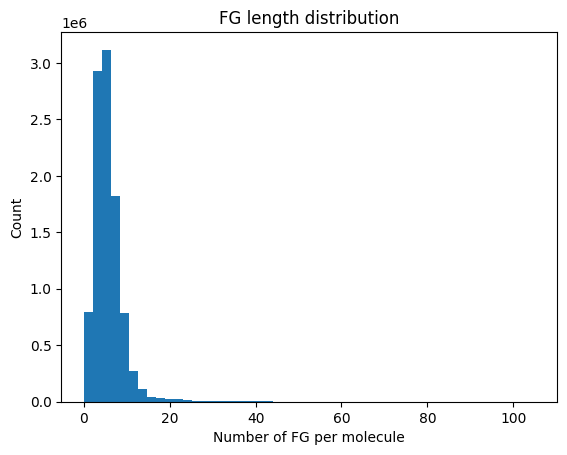

In [ ]:
# FG atom 리스트 길이 분포
from datasets import load_from_disk
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

# 1️⃣ 데이터셋 로드
ds = load_from_disk("./arrow_tr_dataset")

# 2️⃣ fg_atoms 길이 수집
fg_lengths = []

for sample in ds:
    fg = sample["fg_atoms"]
    if fg is None:
        fg_lengths.append(0)
    else:
        fg_lengths.append(len(fg))

fg_lengths = np.array(fg_lengths)

# 3️⃣ 통계 출력
print("Total samples:", len(fg_lengths))
print("Mean:", fg_lengths.mean())
print("Median:", np.median(fg_lengths))
print("Max:", fg_lengths.max())
print("Min:", fg_lengths.min())

# 4️⃣ 빈도 분포 (상위 20개)
counter = Counter(fg_lengths)
print("\nTop counts:")
for k, v in sorted(counter.items())[:20]:
    print(f"{k}: {v}")

# 5️⃣ 히스토그램
plt.hist(fg_lengths, bins=50)
plt.xlabel("Number of FG per molecule")
plt.ylabel("Count")
plt.title("FG length distribution")
plt.show()


[FG groups per sample: len(fg_atoms)]
count: 10011909
mean: 5.873961499250543
median: 5.0
min: 0
max: 105
top 15 values: [(5, 1689353), (4, 1674587), (6, 1427126), (3, 1253864), (7, 1062250), (8, 756311), (2, 633742), (9, 490395), (10, 297820), (11, 165075), (1, 161843), (12, 102590), (13, 67150), (14, 41550), (15, 24525)]

[FG size: atoms per FG element: len(fg)]
count: 58809568
mean: 1.7472322700959138
median: 1.0
min: 1
max: 84
top 15 values: [(1, 40680103), (3, 11216918), (4, 2440371), (2, 2314991), (5, 887206), (6, 522289), (8, 250776), (7, 224426), (9, 95608), (10, 69752), (11, 47830), (12, 24673), (13, 13610), (14, 8060), (15, 5490)]

[SMI token length per sample: len(smi_tokens)]
count: 10011909
mean: 55.117260953929964
median: 50.0
min: 4
max: 512
top 15 values: [(46, 279011), (47, 278620), (48, 278360), (44, 278250), (45, 277514), (49, 273473), (50, 272138), (43, 269864), (51, 266330), (42, 265130), (52, 262769), (53, 255744), (41, 255567), (54, 249110), (40, 244979)]


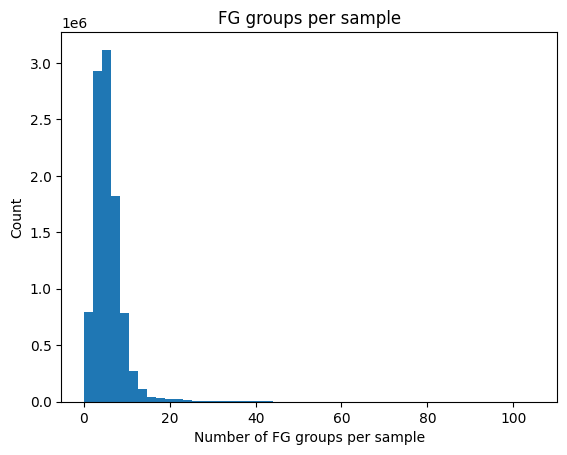

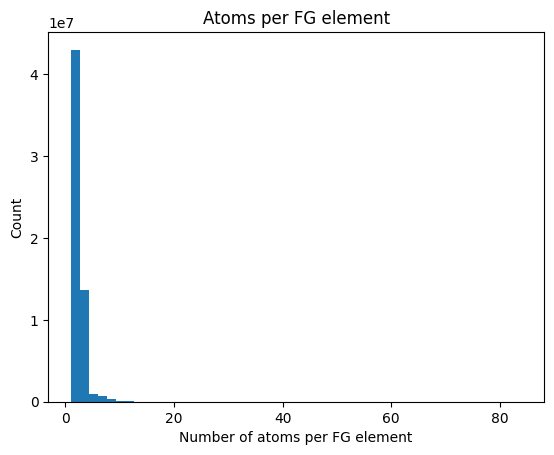

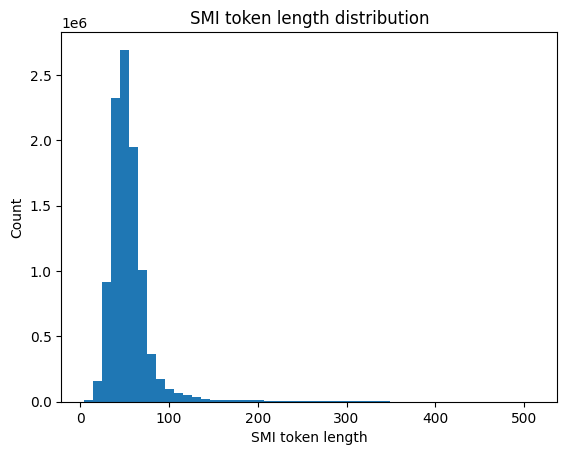


[Extra checks]
ratio fg_atoms==0: 0.00010237807794697295
ratio smi_tokens<=5: 9.288937803969253e-06
ratio smi_tokens>512: 0.0
ratio FG element size==1: 0.691725927998655
ratio FG element size>20: 1.4793511151110649e-05


In [2]:
from datasets import load_from_disk
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

ds = load_from_disk("./arrow_tr_dataset")

# 1) per-sample: number of FG groups (len(fg_atoms))
fg_group_counts = []

# 2) per-FG: size of each FG (len(fg))
fg_element_sizes = []

# 3) per-sample: SMILES token length (len(smi_tokens))
smi_token_lens = []

for sample in ds:
    # --- fg_atoms ---
    fg_list = sample.get("fg_atoms", None)
    if fg_list is None:
        fg_group_counts.append(0)
    else:
        fg_group_counts.append(len(fg_list))
        for fg in fg_list:
            if fg is None:
                continue
            fg_element_sizes.append(len(fg))

    # --- smi_tokens ---
    toks = sample.get("smi_tokens", None)
    if toks is None:
        smi_token_lens.append(0)
    else:
        smi_token_lens.append(len(toks))

fg_group_counts = np.asarray(fg_group_counts, dtype=np.int64)
fg_element_sizes = np.asarray(fg_element_sizes, dtype=np.int64) if len(fg_element_sizes) else np.asarray([], dtype=np.int64)
smi_token_lens = np.asarray(smi_token_lens, dtype=np.int64)

def summarize(arr, name):
    print(f"\n[{name}]")
    print("count:", arr.size)
    if arr.size == 0:
        return
    print("mean:", float(arr.mean()))
    print("median:", float(np.median(arr)))
    print("min:", int(arr.min()))
    print("max:", int(arr.max()))
    # 상위 빈도 일부
    c = Counter(arr.tolist())
    print("top 15 values:", c.most_common(15))

summarize(fg_group_counts, "FG groups per sample: len(fg_atoms)")
summarize(fg_element_sizes, "FG size: atoms per FG element: len(fg)")
summarize(smi_token_lens, "SMI token length per sample: len(smi_tokens)")

# ---- plots ----
plt.figure()
plt.hist(fg_group_counts, bins=50)
plt.xlabel("Number of FG groups per sample")
plt.ylabel("Count")
plt.title("FG groups per sample")
plt.show()

if fg_element_sizes.size > 0:
    plt.figure()
    plt.hist(fg_element_sizes, bins=50)
    plt.xlabel("Number of atoms per FG element")
    plt.ylabel("Count")
    plt.title("Atoms per FG element")
    plt.show()

plt.figure()
plt.hist(smi_token_lens, bins=50)
plt.xlabel("SMI token length")
plt.ylabel("Count")
plt.title("SMI token length distribution")
plt.show()

# ---- useful ratios ----
print("\n[Extra checks]")
print("ratio fg_atoms==0:", float((fg_group_counts == 0).mean()))
print("ratio smi_tokens<=5:", float((smi_token_lens <= 5).mean()))
print("ratio smi_tokens>512:", float((smi_token_lens > 512).mean()))
if fg_element_sizes.size > 0:
    print("ratio FG element size==1:", float((fg_element_sizes == 1).mean()))
    print("ratio FG element size>20:", float((fg_element_sizes > 20).mean()))

In [4]:
import numpy as np

ds = load_from_disk("./arrow_tr_dataset")

N = len(ds)

# 예시: 8% 지점 ±100 샘플
center = int(N * 0.087)
window = 100000

start = max(0, center - window)
end = min(N, center + window)

print("Checking samples:", start, "to", end)

for i in range(start, end):
    sample = ds[i]

    fg_len = len(sample["fg_atoms"]) if sample["fg_atoms"] is not None else 0
    smi_len = len(sample["smi_tokens"]) if sample["smi_tokens"] is not None else 0

    if smi_len < 5 or smi_len > 512 or fg_len == 0:
        print(f"⚠️ idx={i}  fg_len={fg_len}  smi_len={smi_len}")

Checking samples: 771036 to 971036
⚠️ idx=875824  fg_len=0  smi_len=13
⚠️ idx=875825  fg_len=0  smi_len=13
⚠️ idx=875826  fg_len=0  smi_len=15
⚠️ idx=875827  fg_len=0  smi_len=13
⚠️ idx=875828  fg_len=0  smi_len=15
⚠️ idx=936217  fg_len=0  smi_len=15
⚠️ idx=936218  fg_len=0  smi_len=15
⚠️ idx=936219  fg_len=0  smi_len=15
⚠️ idx=936220  fg_len=0  smi_len=15
⚠️ idx=936221  fg_len=0  smi_len=15


In [ ]:
import torch
from datasets import load_from_disk
from torch.utils.data import DataLoader
from FG_masking_collator_new import FG_masking_collator
from pytoda.smiles.smiles_language import SMILESTokenizer
# 1) load
ds = load_from_disk("./arrow_tr_dataset")
tokenizer = SMILESTokenizer(vocab_file="smiles_tokenizer_pytoda/vocab.json",
                                canonical=False,
                                sanitize=True)
collator = FG_masking_collator(tokenizer)
# 2) torch로 나오게 (이미 해놨으면 생략 가능)
ds.set_format(type="torch", columns=ds.column_names)

# 3) (권장) 인덱스 컬럼 추가
if "idx" not in ds.column_names:
    ds = ds.add_column("idx", list(range(len(ds))))
    ds.set_format(type="torch", columns=ds.column_names)

# 4) loader
loader = DataLoader(
    ds,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    collate_fn=collator,   # 네 FG_masking_collator
)

bad_indices = []
checked = 0

for step, batch in enumerate(loader):
    labels = batch["labels"]  # (B, L)

    # 샘플별로 전부 -100인지 체크
    all_neg100 = (labels == -100).all(dim=1)  # (B,)
    if all_neg100.any():
        # 어떤 원본 샘플인지 idx로 뽑기
        if "idx" in batch:
            idxs = batch["idx"].tolist()
            bad = [idxs[i] for i in all_neg100.nonzero(as_tuple=True)[0].tolist()]
        else:
            # idx가 collator output에 없으면 step 기반으로 대략 위치만
            bad = all_neg100.nonzero(as_tuple=True)[0].tolist()
        bad_indices.extend(bad)

        print(f"\n🚨 step={step} found {all_neg100.sum().item()} samples with ALL -100 labels")
        if "idx" in batch:
            print("sample idxs:", bad[:20], "..." if len(bad) > 20 else "")
        else:
            print("row ids in batch:", bad)

        # 너무 많이 나오면 여기서 멈추고 싶으면
        # break

    checked += labels.size(0)
    if step % 1000 == 0:
        print("checked samples:", checked)

print("\nDone.")
print("Total ALL -100 samples:", len(bad_indices))
if len(bad_indices) > 0:
    print("First 50 indices:", bad_indices[:50])